# Usage of PySpark SQL

In [6]:
from pyspark.sql import SparkSession

spark = (SparkSession.builder
                     .appName("Analyzing an unknown article.")
                     .getOrCreate())


In [7]:
## documentation
spark.read??

In [8]:
file_path = r'music_news.txt' # fill in

In [9]:
article = spark.read.text(file_path)

In [10]:
article

DataFrame[value: string]

In [12]:
from pyspark.sql.functions import col, split
article.select(article.value)
article.select(article['value'])
article.select(col('value'))
article.select('value')

DataFrame[value: string]

In [13]:
article.show(5, truncate=False)

+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|value                                                                                                                                                                                                        

In [14]:
from pyspark.sql.functions import col, split
lines = article.select(split(col('value'), ' ').alias('lines'))
lines.show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|lines                                                         

In [15]:
from pyspark.sql.functions import explode
words = lines.select(explode(col('lines')).alias('word'))
words.show(5, truncate=False)

+-------+
|word   |
+-------+
|There's|
|a      |
|photo  |
|of     |
|me     |
+-------+
only showing top 5 rows


In [16]:
from pyspark.sql.functions import lower
words_lower = words.select(lower(col('word')).alias('word'))
words_lower.show(5, truncate=False)

+-------+
|word   |
+-------+
|there's|
|a      |
|photo  |
|of     |
|me     |
+-------+
only showing top 5 rows


In [17]:
from pyspark.sql.functions import regexp_extract
words_clean = words_lower.select(regexp_extract(col('word'), r'(\W+)?([a-z]+)', 2).alias('word'))
words_clean.show(5, truncate=False)

+-----+
|word |
+-----+
|there|
|a    |
|photo|
|of   |
|me   |
+-----+
only showing top 5 rows


In [18]:
words_clean = words_clean.filter(col('word') != '')
words_clean.show(5, truncate=False)

+-----+
|word |
+-----+
|there|
|a    |
|photo|
|of   |
|me   |
+-----+
only showing top 5 rows


In [19]:
groups = words_clean.groupBy(col('word'))
counts = groups.count()
counts.orderBy(col('count').desc()).show(5, truncate=False)

+----+-----+
|word|count|
+----+-----+
|the |18   |
|and |12   |
|a   |10   |
|was |10   |
|i   |8    |
+----+-----+
only showing top 5 rows


In [20]:
import pyspark.sql.functions as F

counts = (
    spark.read.text(file_path)
    .select(F.split(F.col('value'), ' ').alias('lines'))
    .select(F.explode(F.col('lines')).alias('word'))
    .select(F.lower(F.col('word')).alias('word'))
    .select(F.regexp_extract(F.col('word'), r'(\W+)?([a-z]+)', 2).alias('word'))
    .filter(F.col('word') != '')
    .groupBy(F.col('word'))
    .count()
    .orderBy(F.col('count').desc())
)

In [82]:
counts.show()

+-------+-----+
|   word|count|
+-------+-----+
|jackson|    5|
|   when|    3|
|michael|    3|
|   that|    3|
|   this|    3|
|  those|    2|
|   some|    2|
| estate|    2|
|   back|    2|
|  years|    2|
|  again|    2|
|culture|    2|
|  seems|    2|
|  music|    2|
|   what|    2|
|   been|    2|
| legacy|    2|
|   star|    2|
|   huge|    2|
|  still|    1|
+-------+-----+
only showing top 20 rows


In [83]:
from pyspark.sql.functions import length
counts = counts.filter(length(col('word')) > 3)
counts.head(5)

[Row(word='jackson', count=5),
 Row(word='when', count=3),
 Row(word='michael', count=3),
 Row(word='that', count=3),
 Row(word='this', count=3)]

In [84]:
word_length = words.select(F.length(F.col('word')).alias('word_length'))

In [85]:
word_length.show(5)

+-----------+
|word_length|
+-----------+
|          7|
|          1|
|          5|
|          2|
|          2|
+-----------+
only showing top 5 rows


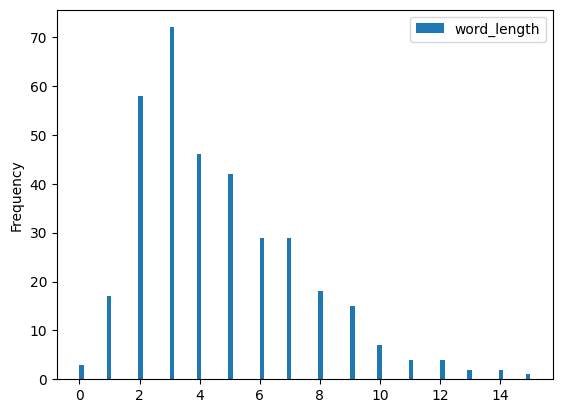

In [86]:
from matplotlib import pyplot as plt

word_length.toPandas().plot(kind='hist', bins=100)
plt.show()

In [108]:
alphabet = words.select(F.split(F.col('word'), '').alias('letters'))
alphabet = alphabet.select(F.explode('letters'))
alphabet = alphabet.select(F.lower(F.col('col')).alias('col'))
alphabet = alphabet.groupBy('col').count()
alphabet = alphabet.filter(F.col("col").rlike("^[a-z]$"))
alphabet = alphabet.orderBy('count', ascending=False)
alphabet.show(5)

+---+-----+
|col|count|
+---+-----+
|  e|  186|
|  a|  153|
|  t|  126|
|  s|  117|
|  i|  108|
+---+-----+
only showing top 5 rows


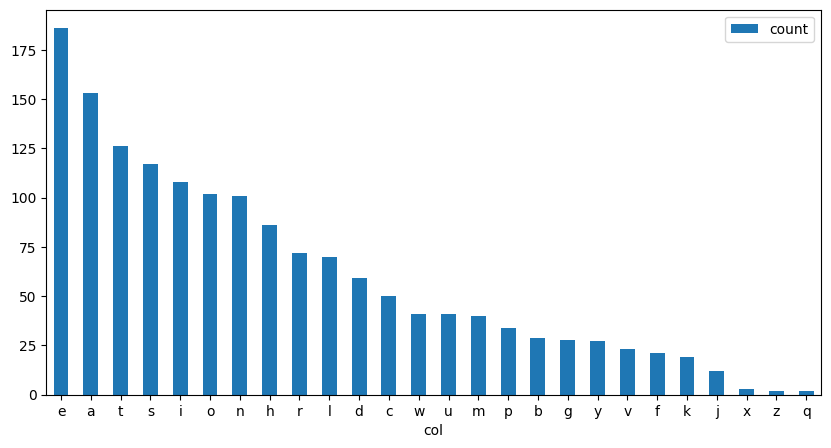

In [109]:

alphabet.toPandas().plot(kind='bar', x='col', y='count', figsize=(10, 5))
plt.xticks(rotation=0)
plt.show()
